# 10 Runx3 ChIP Peak Overlap

Compare CUT&RUN Runx3 peaks (`01_peakEDA`) against previously identified ChIP-seq Runx3 peaks (`source_data/Runx3.bed`, d6) using pairwise Venn diagrams.

## Initialize

In [1]:
# Load Libraries
library(GenomicRanges)
library(VennDiagram)

# Move to working directory
setwd("/home/dalbao/AlbaoRunx3Manuscript/cutnrun")

# Make folder if it does not exist
if (!dir.exists("10_chipOverlap")) {
    dir.create("10_chipOverlap", recursive = TRUE)
}


Loading required package: stats4



Loading required package: BiocGenerics




Attaching package: ‘BiocGenerics’




The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs




The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, intersect, is.unsorted, lapply, Map, mapply,
    match, mget, order, paste, pmax, pmax.int, pmin, pmin.int,
    Position, rank, rbind, Reduce, rownames, sapply, saveRDS, setdiff,
    table, tapply, union, unique, unsplit, which.max, which.min




...

The following objects are masked from ‘package:base’:

    expand.grid, I, unname




Loading required package: IRanges



Loading required package: GenomeInfoDb



Loading required package: grid



Loading required package: futile.logger



## Import Peak Sets

In [2]:
# BED -> GRanges (BED is 0-based half-open; GRanges is 1-based inclusive)
peak_to_gr <- function(path) {
    df <- read.table(path, header = FALSE, sep = "\t", stringsAsFactors = FALSE)
    GRanges(seqnames = df$V1, ranges = IRanges(start = df$V2 + 1, end = df$V3))
}

chip_gr <- peak_to_gr("source_data/Runx3.bed")

peakSets <- list(
    all      = list(path = "01_peakEDA/fullpeak.clean.clustered.named.bed", label = "All CUT&RUN peaks"),
    cluster1 = list(path = "01_peakEDA/cluster1.fullpeak.clean.bed",        label = "Cluster 1 peaks"),
    cluster2 = list(path = "01_peakEDA/cluster2.fullpeak.clean.bed",        label = "Cluster 2 peaks")
)

length(chip_gr)


[1] 5673

## Compute Overlaps and Draw Venn Diagrams

Overlap = number of CUT&RUN peaks with ≥ 1 bp overlap to a ChIP peak. A separate pairwise Venn diagram is drawn (and saved as a PDF in `10_chipOverlap/`) for each CUT&RUN peak set against the ChIP peaks.

In [3]:
options(repr.plot.width = 6.5, repr.plot.height = 5)

plot_overlap_venn <- function(peaks_path, peaks_label, chip_gr, outfile, chip_label = "ChIP Runx3 (d6)") {
    peaks_gr <- peak_to_gr(peaks_path)

    n_peaks   <- length(peaks_gr)
    n_chip    <- length(chip_gr)
    n_overlap <- sum(countOverlaps(peaks_gr, chip_gr) > 0)

    cat(sprintf(
        "%s: %d peaks | %s: %d peaks | overlap: %d %s peaks (%.1f%%) also found in %s\n",
        peaks_label, n_peaks, chip_label, n_chip,
        n_overlap, peaks_label, 100 * n_overlap / n_peaks, chip_label
    ))

    pdf(outfile, width = 6.5, height = 5)
    venn <- draw.pairwise.venn(
        area1          = n_peaks,
        area2          = n_chip,
        cross.area     = n_overlap,
        category       = c(peaks_label, chip_label),
        fill           = c("#4C72B0", "#DD8452"),
        alpha          = 0.6,
        lwd            = 2,
        cex            = 1,
        cat.cex        = 1,
        cat.pos        = c(-30, 30),
        cat.dist       = c(0.03, 0.03),
        fontfamily     = "sans",
        cat.fontfamily = "sans"
    )
    dev.off()

    grid.newpage()
    grid.draw(venn)

    invisible(c(n_peaks = n_peaks, n_chip = n_chip, n_overlap = n_overlap))
}


### All peaks vs ChIP

All CUT&RUN peaks: 4172 peaks | ChIP Runx3 (d6): 5673 peaks | overlap: 1096 All CUT&RUN peaks peaks (26.3%) also found in ChIP Runx3 (d6)


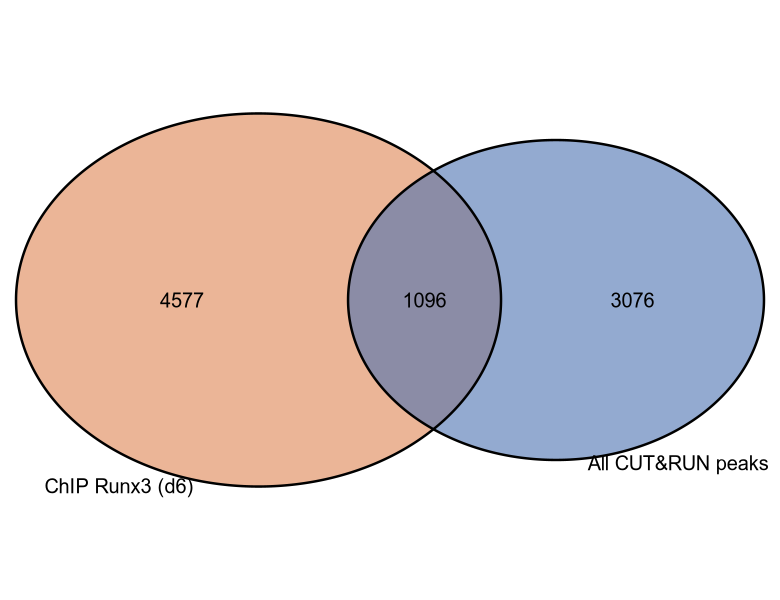

In [4]:
plot_overlap_venn(
    peakSets$all$path, peakSets$all$label, chip_gr,
    outfile = "10_chipOverlap/venn_all_vs_ChIP.pdf"
)


### Cluster 1 vs ChIP

Cluster 1 peaks: 1190 peaks | ChIP Runx3 (d6): 5673 peaks | overlap: 381 Cluster 1 peaks peaks (32.0%) also found in ChIP Runx3 (d6)


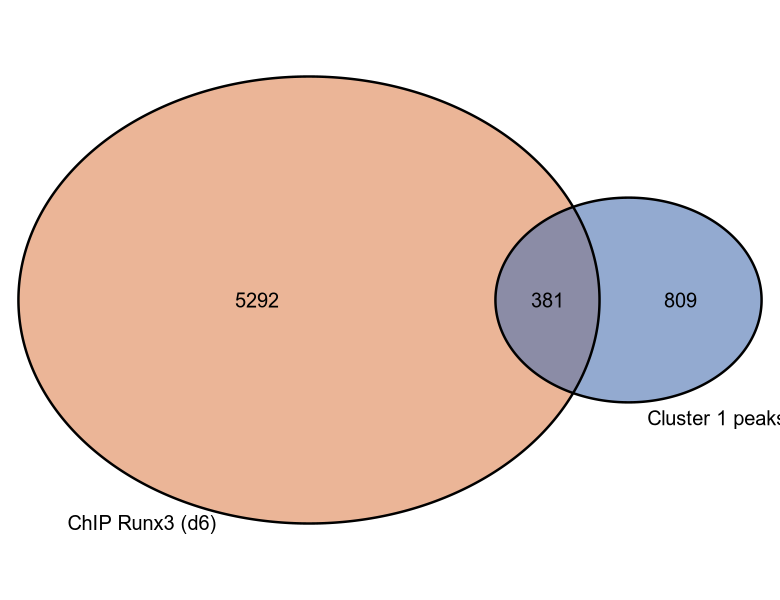

In [5]:
plot_overlap_venn(
    peakSets$cluster1$path, peakSets$cluster1$label, chip_gr,
    outfile = "10_chipOverlap/venn_cluster1_vs_ChIP.pdf"
)


### Cluster 2 vs ChIP

Cluster 2 peaks: 2982 peaks | ChIP Runx3 (d6): 5673 peaks | overlap: 715 Cluster 2 peaks peaks (24.0%) also found in ChIP Runx3 (d6)


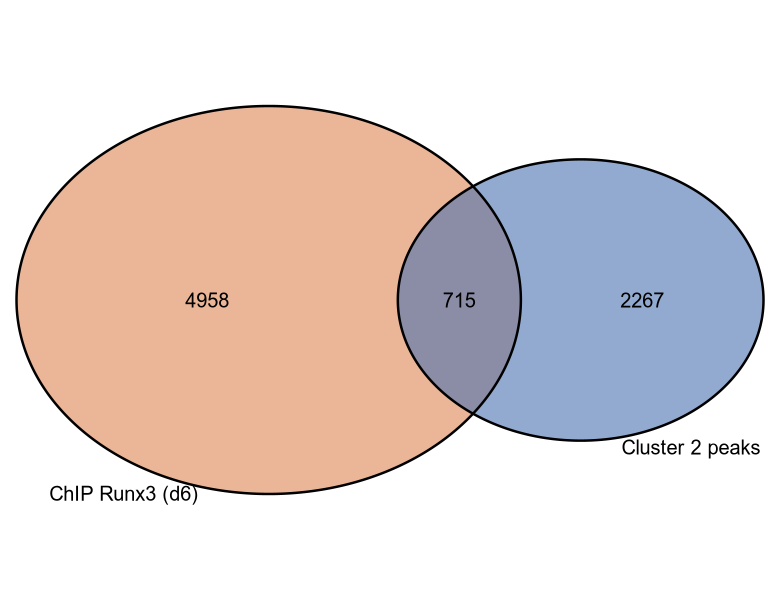

In [6]:
plot_overlap_venn(
    peakSets$cluster2$path, peakSets$cluster2$label, chip_gr,
    outfile = "10_chipOverlap/venn_cluster2_vs_ChIP.pdf"
)
